In [1]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio

pd.set_option("display.max_columns", None)

FS = 2000  # DB2 샘플링 주파수 (Hz)
mat = sio.loadmat("data/ninapro_db2/s1/S1_E1_A1.mat")
n = mat["emg"].shape[0]

# 시간에 따라 기록된 변수만 골라 CSV처럼 한 표로 합친다 (행 = 1/2000초)
series_keys = ["emg", "glove", "acc", "inclin",
               "stimulus", "repetition", "restimulus", "rerepetition"]
cols = {"time": np.arange(n) / FS}
for key in series_keys:
    arr = mat[key]
    if arr.shape[1] == 1:
        cols[key] = arr[:, 0]
    else:
        for i in range(arr.shape[1]):
            cols[f"{key}_{i + 1}"] = arr[:, i]

df = pd.DataFrame(cols)
print(df.shape)
df.head(10)

(1808331, 77)


,time,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,emg_9,emg_10,emg_11,emg_12,glove_1,glove_2,glove_3,glove_4,glove_5,glove_6,glove_7,glove_8,glove_9,glove_10,glove_11,glove_12,glove_13,glove_14,glove_15,glove_16,glove_17,glove_18,glove_19,glove_20,glove_21,glove_22,acc_1,acc_2,acc_3,acc_4,acc_5,acc_6,acc_7,acc_8,acc_9,acc_10,acc_11,acc_12,acc_13,acc_14,acc_15,acc_16,acc_17,acc_18,acc_19,acc_20,acc_21,acc_22,acc_23,acc_24,acc_25,acc_26,acc_27,acc_28,acc_29,acc_30,acc_31,acc_32,acc_33,acc_34,acc_35,acc_36,inclin_1,inclin_2,stimulus,repetition,restimulus,rerepetition
0,0.0000,-2.851210e-06,3.355261e-06,1.598866e-06,-0.000001,-0.000002,2.749975e-06,-2.347791e-06,1.537436e-07,-2.484787e-07,1.469924e-06,-5.609089e-06,0.000040,63.025558,6.871781,13.948268,-3.736244,34.733021,24.408056,5.098587,40.896095,36.783451,-1.881887,483.528595,31.431458,34.730904,-13.20356,3.134116,32.064075,24.996765,-4.602355,14.1388,33.340313,12.35292,7.623547,0.140237,0.954054,0.279233,0.035302,0.338504,0.818042,0.063213,-0.27509,0.737374,0.109309,-0.882731,0.044982,0.243956,-0.837242,-0.552029,0.117150,-0.279778,-1.058164,0.081213,0.507948,-1.024088,0.064549,1.004516,-0.299793,-0.158943,-0.922046,-0.179319,0.165622,0.658064,-0.887909,0.765372,-0.579451,-0.126897,0.875372,0.417032,-0.04865,60.424751,-0.610250,0,0,0,1
1,0.0005,-4.697738e-06,3.355212e-06,1.430441e-06,-0.000003,-0.000003,2.246543e-06,-1.657156e-07,2.503453e-06,-3.561109e-07,2.478162e-06,-3.259393e-06,0.000050,63.025558,6.871781,13.948268,-3.736244,34.733021,24.408056,5.098587,40.896095,36.783451,-1.881887,483.528595,31.431458,34.730904,-13.20356,3.134116,32.064075,24.996765,-4.602355,14.1388,33.340313,12.35292,7.623547,0.140237,0.954054,0.278069,0.036479,0.338504,0.818042,0.063213,-0.27509,0.737374,0.109309,-0.882731,0.043782,0.243956,-0.836088,-0.552029,0.118351,-0.279778,-1.058164,0.081213,0.507948,-1.024088,0.064549,1.004516,-0.299793,-0.158943,-0.922046,-0.179319,0.164483,0.658064,-0.887909,0.765372,-0.579451,-0.126897,0.875372,0.417032,-0.04865,60.424751,-0.609004,0,0,0,1
2,0.0010,-2.683734e-06,4.026560e-06,9.263165e-07,-0.000005,-0.000004,1.239568e-06,2.352061e-06,5.524560e-06,-2.445606e-07,2.479306e-06,-7.045269e-08,0.000047,63.025558,6.871781,13.948268,-3.736244,34.733021,24.408056,5.098587,40.896095,36.783451,-1.881887,483.528595,31.431458,34.730904,-13.20356,3.134116,32.064075,24.996765,-4.602355,14.1388,33.340313,12.35292,7.623547,0.140237,0.954054,0.276906,0.037656,0.338504,0.818042,0.063213,-0.27509,0.737374,0.109309,-0.882731,0.042583,0.243956,-0.834935,-0.552029,0.119553,-0.279778,-1.058164,0.081213,0.507948,-1.024088,0.064549,1.004516,-0.299793,-0.158943,-0.922046,-0.179319,0.163345,0.658064,-0.887909,0.765372,-0.579451,-0.126897,0.875372,0.417032,-0.04865,60.424751,-0.605954,0,0,0,1
3,0.0015,2.183707e-06,2.851566e-06,7.578904e-07,-0.000007,-0.000004,1.575385e-06,2.016400e-06,5.188681e-06,1.094450e-06,2.816148e-06,1.439995e-06,0.000032,63.025558,6.871781,13.948268,-3.736244,34.733021,24.408056,5.098587,40.896095,36.783451,-1.881887,483.528595,31.431458,34.730904,-13.20356,3.134116,32.064075,24.996765,-4.602355,14.1388,33.340313,12.35292,7.623547,0.140237,0.954054,0.275742,0.038832,0.338504,0.818042,0.063213,-0.27509,0.737374,0.109309,-0.882731,0.041384,0.243956,-0.833782,-0.552029,0.120754,-0.279778,-1.058164,0.081213,0.507948,-1.024088,0.064549,1.004516,-0.299793,-0.158943,-0.922046,-0.179319,0.162207,0.658064,-0.887909,0.765372,-0.579451,-0.126897,0.875372,0.417032,-0.04865,60.424751,-0.602904,0,0,0,1
4,0.0020,4.197711e-06,6.694763e-07,1.764409e-06,-0.000005,-0.000006,7.362596e-07,8.414949e-07,8.244234e-07,1.154750e-06,2.817293e-06,9.700835e-08,0.000014,63.025558,6.871781,13.948268,-3.736244,34.733021,24.408056,5.098587,40.896095,36.783451,-1.881887,483.528595,31.431458,34.730904,-13.20356,3.134116,32.064075,24.996765,-4.602355,14.1388,33.340313,12.35292,7.623547,0.140237,0.954054,0.274579,0.040009,0.338504,0.818042,0.063213,-0.27509,0.737374,0.109309,-0.882731,0.040184,

In [2]:
# 실습 단계 3: 데이터 구조 파악
# 강의의 4가지 손동작에 해당하는 DB2 Exercise 1 동작 번호 (공식 문서로 확인 필요)
CLASSES = {5: "open", 6: "fist", 9: "supination", 10: "pronation"}
PAD = 1.0  # 시행 앞뒤로 붙일 휴식 (초). 동작 사이 휴식은 최소 2.13초라 옆 시행과 겹치지 않는다


def find_trials(restimulus, rerepetition):
    """restimulus 값이 바뀌는 지점으로 연속 구간을 나눠 동작 구간(시행)만 돌려준다."""
    change = np.flatnonzero(np.diff(restimulus)) + 1
    starts = np.r_[0, change]
    ends = np.r_[change, len(restimulus)]
    return [(int(restimulus[s]), int(rerepetition[s]), s, e)
            for s, e in zip(starts, ends) if restimulus[s] != 0]


# 40명 전체에서 4개 동작의 시행을 잘라낸다 (실습의 CSV 파일 하나 = trial_emg 원소 하나)
rows, trial_emg = [], []
pad = int(PAD * FS)
files = sorted(Path("data/ninapro_db2").glob("s*/S*_E1_A1.mat"),
               key=lambda p: int(p.parent.name[1:]))
for path in files:
    m = sio.loadmat(path, variable_names=["emg", "restimulus", "rerepetition"])
    subject = int(path.parent.name[1:])
    for label, rep, s, e in find_trials(m["restimulus"].ravel(), m["rerepetition"].ravel()):
        if label not in CLASSES:
            continue
        # 휴식 1초 + 동작 + 휴식 1초. copy 하지 않으면 원본 전체가 메모리에 남는다
        trial_emg.append(m["emg"][s - pad:e + pad].copy())
        rows.append({"subject": subject, "class": CLASSES[label], "label": label, "rep": rep,
                     "n_samples": e - s,
                     "onset": PAD, "offset": PAD + (e - s) / FS})  # 잘라낸 시행 안에서 동작 시작·끝 (초)

trials = pd.DataFrame(rows)
trials["seconds"] = trials["n_samples"] / FS

print("파일 수:", len(files))
print("시행 수:", len(trial_emg))
print("배열 모양 (첫 시행):", trial_emg[0].shape)
print("채널 수:", trial_emg[0].shape[1])
print("\n클래스별 시행 수:", Counter(trials["class"]))

counts = trials.pivot_table(index="subject", columns="class", values="rep", aggfunc="count")
missing = list(counts.index[(counts != 6).any(axis=1)])
print("피험자별 6회가 안 되는 경우:", missing or "없음")

print("\n동작 구간 길이 (초):")
display(trials.groupby("class")["seconds"].describe().round(2))
trials.head(10)

파일 수: 40
시행 수: 960
배열 모양 (첫 시행): (11026, 12)
채널 수: 12

클래스별 시행 수: Counter({'open': 240, 'fist': 240, 'supination': 240, 'pronation': 240})
피험자별 6회가 안 되는 경우: 없음

동작 구간 길이 (초):


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
fist,240.0,3.95,1.72,1.94,2.45,3.31,6.30,6.61
open,240.0,4.52,1.77,1.94,2.78,3.87,6.41,6.61
pronation,240.0,4.79,1.59,1.91,3.45,5.01,6.33,6.69
supination,240.0,4.88,1.43,1.91,3.61,5.01,6.41,6.60


,subject,class,label,rep,n_samples,onset,offset,seconds
0,1,open,5,1,7026,1.0,4.5130,3.5130
1,1,open,5,2,7029,1.0,4.5145,3.5145
2,1,open,5,3,7405,1.0,4.7025,3.7025
3,1,open,5,4,6727,1.0,4.3635,3.3635
4,1,open,5,5,6351,1.0,4.1755,3.1755
5,1,open,5,6,5587,1.0,3.7935,2.7935
6,1,fist,6,1,4485,1.0,3.2425,2.2425
7,1,fist,6,2,4506,1.0,3.2530,2.2530
8,1,fist,6,3,4345,1.0,3.1725,2.1725
9,1,fist,6,4,4346,1.0,3.1730,2.1730


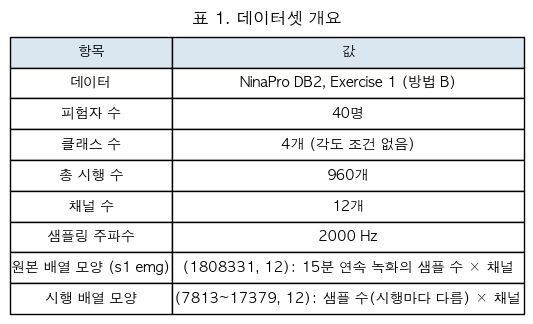

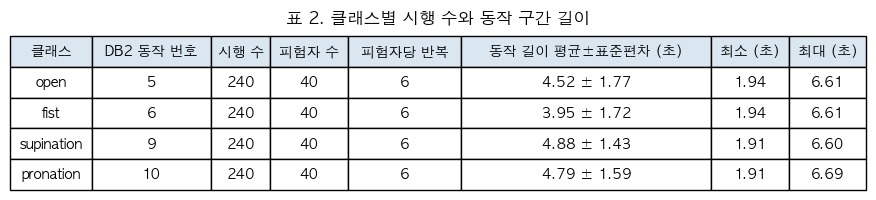

,항목,값
0,데이터,"NinaPro DB2, Exercise 1 (방법 B)"
1,피험자 수,40명
2,클래스 수,4개 (각도 조건 없음)
3,총 시행 수,960개
4,채널 수,12개
5,샘플링 주파수,2000 Hz
6,원본 배열 모양 (s1 emg),"(1808331, 12): 15분 연속 녹화의 샘플 수 × 채널"
7,시행 배열 모양,"(7813~17379, 12): 샘플 수(시행마다 다름) × 채널"


,클래스,DB2 동작 번호,시행 수,피험자 수,피험자당 반복,동작 길이 평균±표준편차 (초),최소 (초),최대 (초)
0,open,5,240,40,6,4.52 ± 1.77,1.94,6.61
1,fist,6,240,40,6,3.95 ± 1.72,1.94,6.61
2,supination,9,240,40,6,4.88 ± 1.43,1.91,6.60
3,pronation,10,240,40,6,4.79 ± 1.59,1.91,6.69


In [3]:
# 제출물 ② 데이터 요약: 표를 만들어 리포트 첨부용 이미지(PNG)로 저장
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"   # macOS 한글 폰트 (Windows는 "Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False
FIG_DIR = Path("figures/week_1")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 표 1: 데이터셋 개요
lengths = [len(x) for x in trial_emg]
overview = pd.DataFrame({
    "항목": ["데이터", "피험자 수", "클래스 수", "총 시행 수", "채널 수", "샘플링 주파수",
             "원본 배열 모양 (s1 emg)", "시행 배열 모양"],
    "값": ["NinaPro DB2, Exercise 1 (방법 B)",
           f"{trials['subject'].nunique()}명",
           f"{trials['class'].nunique()}개 (각도 조건 없음)",
           f"{len(trial_emg)}개",
           f"{trial_emg[0].shape[1]}개",
           f"{FS} Hz",
           f"{mat['emg'].shape}: 15분 연속 녹화의 샘플 수 × 채널",
           f"({min(lengths)}~{max(lengths)}, {trial_emg[0].shape[1]}): 샘플 수(시행마다 다름) × 채널"],
})

# 표 2: 클래스별 요약
by_class = trials.groupby("class", sort=False)
class_table = pd.DataFrame({
    "클래스": list(by_class.groups),
    "DB2 동작 번호": by_class["label"].first().values,
    "시행 수": by_class.size().values,
    "피험자 수": by_class["subject"].nunique().values,
    "피험자당 반복": (by_class.size() / by_class["subject"].nunique()).astype(int).values,
    "동작 길이 평균±표준편차 (초)": [f"{m:.2f} ± {s:.2f}" for m, s in
                                zip(by_class["seconds"].mean(), by_class["seconds"].std())],
    "최소 (초)": [f"{v:.2f}" for v in by_class["seconds"].min()],
    "최대 (초)": [f"{v:.2f}" for v in by_class["seconds"].max()],
})


def text_width(s):
    """한글은 영문·숫자보다 폭이 두 배쯤 넓으므로 2칸으로 센다."""
    return sum(2 if ord(c) > 0x1100 else 1 for c in str(s))


def save_table(table, name, title):
    """DataFrame을 표 이미지(PNG)로 저장한다."""
    # 열마다 가장 긴 글자 폭을 더해 그림 폭을 정한다 (글자가 칸 밖으로 넘치지 않게)
    chars = sum(max(text_width(v) for v in [col, *table[col]]) + 4 for col in table.columns)
    fig, ax = plt.subplots(figsize=(chars * 0.085, 0.4 * (len(table) + 1)))
    ax.axis("off")
    tbl = ax.table(cellText=table.values, colLabels=table.columns, cellLoc="center",
                   bbox=[0, 0, 1, 1])  # 표가 그림 전체를 채우게 해서 제목과의 빈 공간을 없앤다
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width(range(len(table.columns)))
    for (row, _), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#dbe7f0")
            cell.set_text_props(weight="bold")
    ax.set_title(title, fontsize=12, pad=10)
    plt.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


save_table(overview, "data_overview", "표 1. 데이터셋 개요")
save_table(class_table, "class_summary", "표 2. 클래스별 시행 수와 동작 구간 길이")
display(overview, class_table)

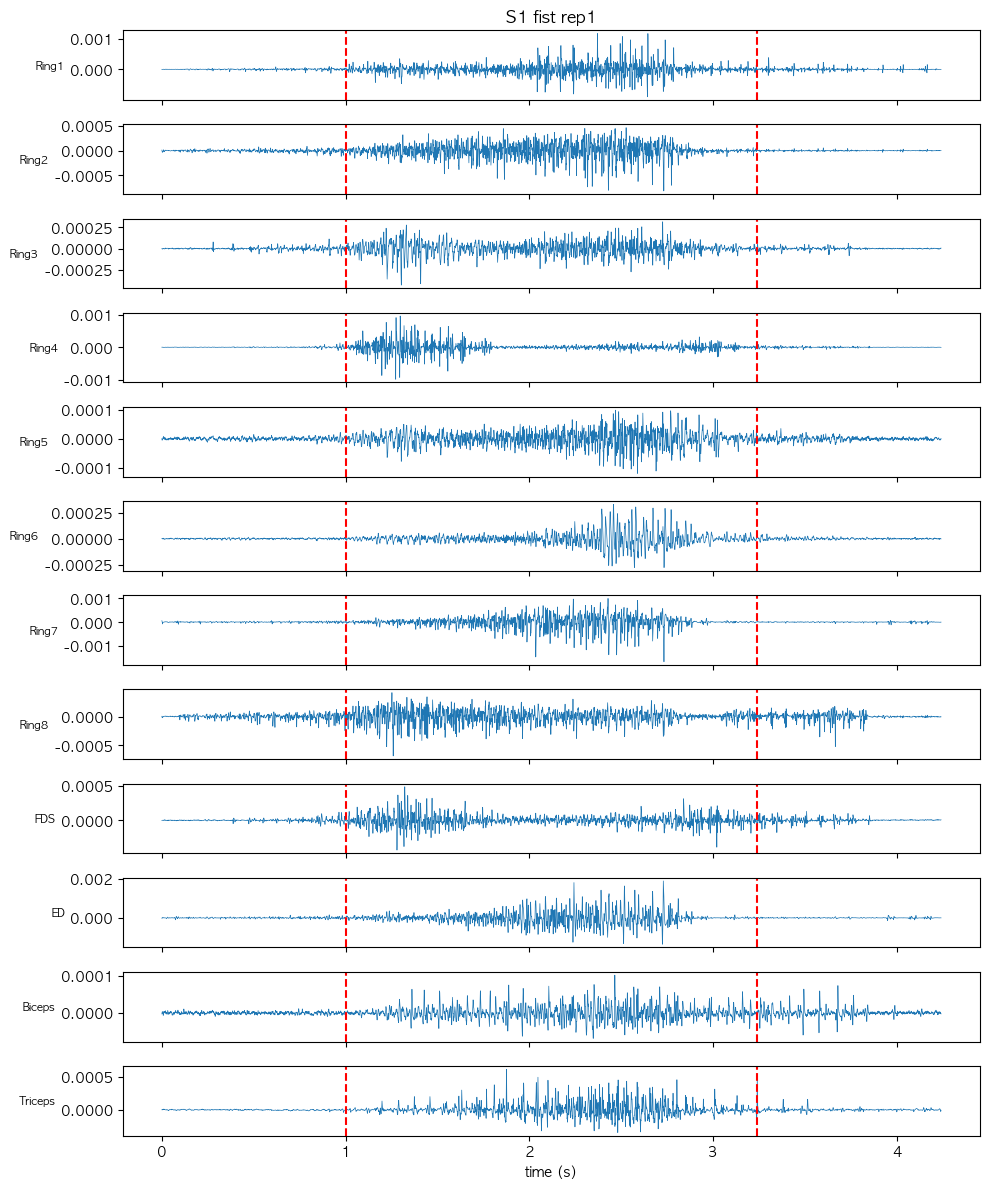

In [4]:
# 실습 단계 4-1: 시행 하나의 12채널 파형 (휴식-동작-휴식 3구간 확인)
import matplotlib.pyplot as plt

# DB2 전극 배치: 1~8 전완 둘레, 9 천지굴근, 10 총지신근, 11 상완이두근, 12 상완삼두근
CH_NAMES = [f"Ring{i}" for i in range(1, 9)] + ["FDS", "ED", "Biceps", "Triceps"]

i = trials.query("subject == 1 and `class` == 'fist' and rep == 1").index[0]
x = trial_emg[i]
info = trials.loc[i]
t = np.arange(len(x)) / FS  # DB2는 2 kHz

fig, ax = plt.subplots(12, 1, figsize=(10, 12), sharex=True)
for ch in range(12):
    ax[ch].plot(t, x[:, ch], lw=0.5)
    ax[ch].set_ylabel(CH_NAMES[ch], fontsize=8, rotation=0, ha="right", va="center")
    ax[ch].axvline(info["onset"], color="r", ls="--")   # 동작 시작
    ax[ch].axvline(info["offset"], color="r", ls="--")  # 동작 끝
ax[0].set_title(f"S{info['subject']} {info['class']} rep{info['rep']}")
ax[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch12_example.png", dpi=120)
plt.show()

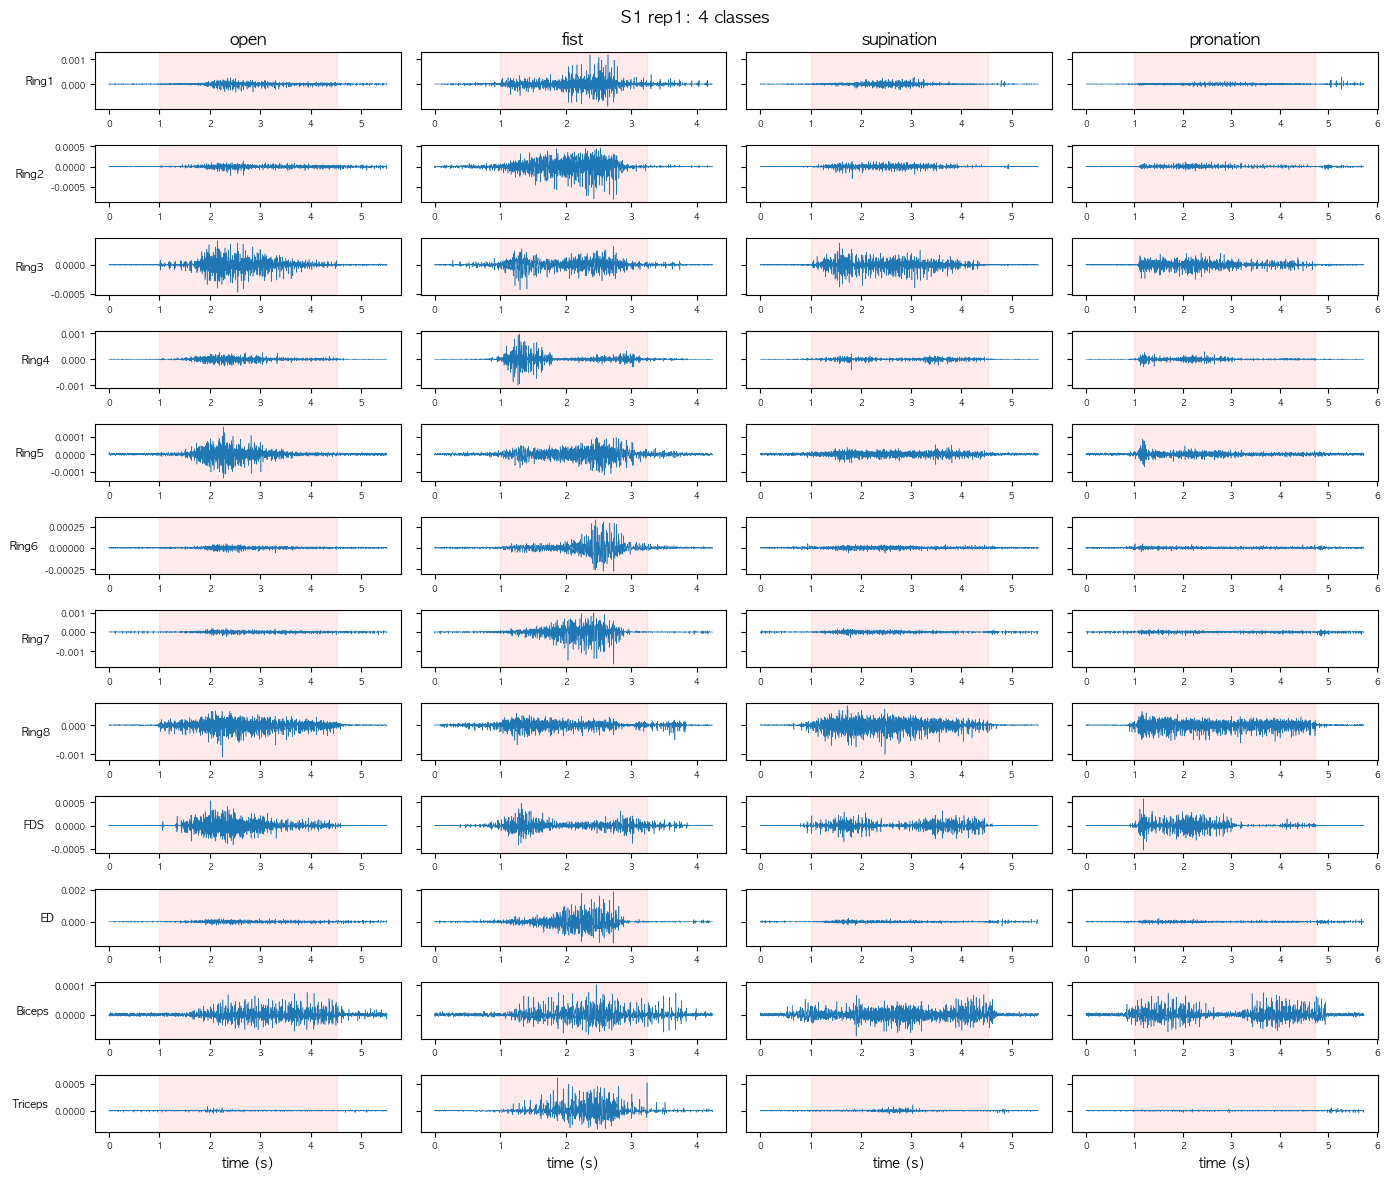

In [5]:
# 실습 단계 4-2: 같은 피험자·같은 회차에서 4개 동작 비교 (채널별로 y축 범위를 맞춰 진폭을 비교)
subject, rep = 1, 1

fig, ax = plt.subplots(12, 4, figsize=(14, 12), sharey="row")
for col, cls in enumerate(CLASSES.values()):
    i = trials.query("subject == @subject and `class` == @cls and rep == @rep").index[0]
    x = trial_emg[i]
    t = np.arange(len(x)) / FS
    for ch in range(12):
        a = ax[ch, col]
        a.plot(t, x[:, ch], lw=0.4)
        a.axvspan(trials.loc[i, "onset"], trials.loc[i, "offset"], color="r", alpha=0.08)
        a.tick_params(labelsize=6)
        if col == 0:
            a.set_ylabel(CH_NAMES[ch], fontsize=8, rotation=0, ha="right", va="center")
    ax[0, col].set_title(cls)
    ax[-1, col].set_xlabel("time (s)")
fig.suptitle(f"S{subject} rep{rep}: 4 classes")
plt.tight_layout()
plt.savefig(FIG_DIR / "classes_compare.png", dpi=120)
plt.show()

In [6]:
# 4-3: 40명 전체에서 동작별 채널 활성 비교 (4-2의 관찰이 피험자 1명에게만 해당하는지 확인)
# 동작 구간의 채널별 RMS를 구하고, 피험자마다 진폭 수준이 다르므로
# 피험자·채널별로 4개 동작 평균이 1이 되도록 정규화한 뒤 40명 평균을 낸다
rms = np.array([np.sqrt((x[pad:-pad] ** 2).mean(axis=0)) for x in trial_emg])
rest = np.array([np.sqrt((np.r_[x[:pad], x[-pad:]] ** 2).mean(axis=0)) for x in trial_emg])
print("동작/휴식 RMS 비 (중앙값):", np.median(rms / rest).round(1))

per_subject = (pd.concat([trials[["subject", "class"]], pd.DataFrame(rms, columns=CH_NAMES)], axis=1)
               .groupby(["subject", "class"])[CH_NAMES].mean())
norm_rms = per_subject / per_subject.groupby("subject").transform("mean")

# 피험자 간 일관성: 같은 동작의 12채널 패턴이 피험자끼리 얼마나 비슷한지 (상관계수 중앙값)
iu = np.triu_indices(trials["subject"].nunique(), 1)
consistency = {cls: round(float(np.median(np.corrcoef(norm_rms.xs(cls, level="class").values)[iu])), 2)
               for cls in CLASSES.values()}
print("피험자 간 패턴 상관 (중앙값):", consistency)

norm_rms.groupby("class").mean().loc[list(CLASSES.values())].T.round(2)


동작/휴식 RMS 비 (중앙값): 2.6
피험자 간 패턴 상관 (중앙값): {'open': 0.24, 'fist': 0.47, 'supination': 0.71, 'pronation': 0.24}


class,open,fist,supination,pronation
Ring1,0.80,1.45,0.78,0.97
Ring2,0.77,2.03,0.64,0.56
Ring3,1.06,1.46,0.79,0.68
Ring4,1.06,1.11,0.72,1.11
Ring5,0.89,1.02,0.90,1.19
Ring6,0.82,1.32,0.91,0.95
Ring7,0.87,1.52,0.80,0.81
Ring8,1.15,0.95,0.94,0.95
FDS,1.03,1.33,0.71,0.93
ED,1.03,1.34,0.70,0.93
